## Load the celebA Dataset

In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define the same transforms as before
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # RGB → 1 channel
    transforms.Resize((64, 64)),                 # Resize to 64x64
    transforms.ToTensor()                        # Convert to [0, 1] tensor
])

# 2. Point to the ROOT directory
# Note: root should contain a sub-folder (e.g., 'img_align_celeba') 
# that holds the .jpg files.
root_path = "../data/celeba" 

dataset = datasets.ImageFolder(
    root=root_path,
    transform=transform
)

# 3. Create the Loader
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Sanity check: Print number of images
print(f"Total images loaded: {len(dataset)}")

Total images loaded: 23429


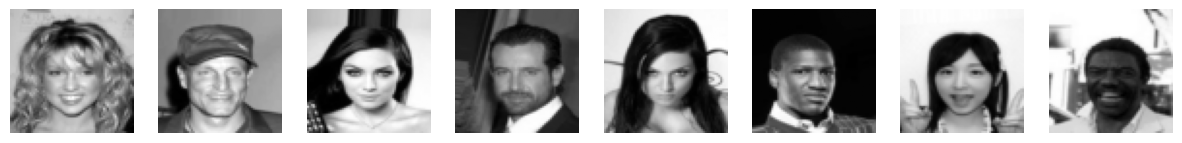

In [2]:
import matplotlib.pyplot as plt

images, labels = next(iter(loader))

fig, axes = plt.subplots(1, 8, figsize=(15,3))

for i in range(8):
    axes[i].imshow(images[i].permute(1,2,0), cmap = "grey")
    axes[i].axis("off")

plt.show()

## Model Building

In [3]:
import torch
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F


import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        
        # Layer 1: 64 -> 32
        self.conv1 = nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        
        # Layer 2: 32 -> 16
        self.conv2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        
        # Layer 3: 16 -> 8
        self.conv3 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        # Layer 4: 8 -> 4
        self.conv4 = nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(512)

        self.flatten = nn.Flatten()
        
        # Flattened size is 512 * 4 * 4 = 8192
        self.fc_mean = nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(512 * 4 * 4, latent_dim)

    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = F.relu(self.bn2(self.conv2(h)))
        h = F.relu(self.bn3(self.conv3(h)))
        h = F.relu(self.bn4(self.conv4(h))) # Added forward for layer 4

        h = self.flatten(h)
        mu = self.fc_mean(h)
        log_var = self.fc_logvar(h)
        return mu, log_var
    
    def reparameterization(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)

        return mu + eps * std

class CNNDecoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        
        # Start from 4x4 bottleneck
        self.fc = nn.Linear(latent_dim, 512 * 4 * 4)
        
        # Layer 1: 4 -> 8
        self.deconv1 = nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(256)
        
        # Layer 2: 8 -> 16
        self.deconv2 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        
        # Layer 3: 16 -> 32
        self.deconv3 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        # Layer 4: 32 -> 64
        self.deconv4 = nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1)

    def forward(self, z):
        h = self.fc(z)
        h = h.view(-1, 512, 4, 4)
        
        h = F.relu(self.bn1(self.deconv1(h)))
        h = F.relu(self.bn2(self.deconv2(h)))
        h = F.relu(self.bn3(self.deconv3(h)))
        
        return torch.sigmoid(self.deconv4(h))

class CNNVAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = CNNEncoder(latent_dim)
        self.decoder = CNNDecoder(latent_dim)
    
    def forward(self, x: torch.tensor):
        mean, log_var = self.encoder(x)
        z = self.encoder.reparameterization(mean, log_var)
        logits = self.decoder(z)
        return (mean, log_var), logits
    
    def kl_divergence(self, mu: torch.tensor, log_var: torch.tensor):
        return -0.5 * torch.sum(1 + log_var - torch.exp(log_var) - mu.pow(2), dim=-1)

def train_vae_model(model, loader, epochs, optimizer, device, anneal_epochs=40):
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        total_recon_loss = 0
        total_kl_loss = 0
        
        # Beta annealing for KL Divergence
        beta = min(1.0, epoch / anneal_epochs)
        
        # tqdm setup with a description
        batch_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)

        for images, _ in batch_bar:
            x = images.to(device)

            # Forward pass
            (mean, log_var), reconstructed_x = model(x)
            
            # 1. Reconstruction Loss (Binary Cross Entropy)
            # Use F.binary_cross_entropy if you added Sigmoid to the decoder
            recon_loss = F.binary_cross_entropy(reconstructed_x, x, reduction="mean")
            
            # 2. KL Divergence Loss
            kl_val = model.kl_divergence(mean, log_var)
            kl_loss = torch.mean(kl_val)

            # Combined Loss with scaling (Adjust 0.001 based on performance)
            combined_loss = recon_loss + (kl_loss * beta * 0.0001)

            # Backward pass
            optimizer.zero_grad()
            combined_loss.backward()
            optimizer.step()

            # Stats for logging
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_loss.item()

            # Update tqdm bar with both losses
            batch_bar.set_postfix({
                "Recon": f"{recon_loss.item():.4f}",
                "KL": f"{kl_loss.item():.4f}",
                "Beta": f"{beta:.2f}"
            })

        avg_recon = total_recon_loss / len(loader)
        avg_kl = total_kl_loss / len(loader)
        
        print(f"==> Epoch {epoch} Complete | Avg Recon: {avg_recon:.4f} | Avg KL: {avg_kl:.4f}")

    return model

## Model Traning

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
in_features = images[0].shape[-1] * images[0].shape[-1]
out_features = images[0].shape[-1] * images[0].shape[-1]
latent_dim = 64
lr = 2e-4
vae = CNNVAE(latent_dim)
optimizer = torch.optim.Adam(params = vae.parameters(), lr = lr)

print(f"Training on device: [{device}]")
trained_vae = train_vae_model(
    model = vae,
    loader = loader,
    epochs = 200,
    optimizer = optimizer,
    device = device
)

Training on device: [cuda]


Epoch 1/200: 100%|██████████| 367/367 [02:42<00:00,  2.26it/s, Recon=0.5310, KL=456.9037, Beta=0.00]           


==> Epoch 0 Complete | Avg Recon: 0.5741 | Avg KL: 2087684952588.8328


Epoch 2/200: 100%|██████████| 367/367 [00:30<00:00, 12.15it/s, Recon=0.4877, KL=302.9373, Beta=0.03]


==> Epoch 1 Complete | Avg Recon: 0.5281 | Avg KL: 312.2473


...

==> Epoch 197 Complete | Avg Recon: 0.5126 | Avg KL: 92.0423


Epoch 199/200: 100%|██████████| 367/367 [00:25<00:00, 14.31it/s, Recon=0.4892, KL=106.4190, Beta=1.00]


==> Epoch 198 Complete | Avg Recon: 0.5126 | Avg KL: 92.0385


Epoch 200/200: 100%|██████████| 367/367 [00:25<00:00, 14.14it/s, Recon=0.5763, KL=105.5406, Beta=1.00]

==> Epoch 199 Complete | Avg Recon: 0.5128 | Avg KL: 91.9758


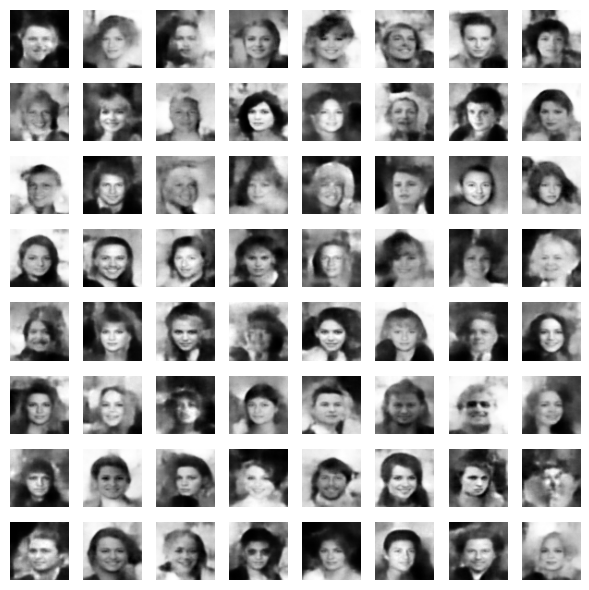

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def generate_new_images(model, n_images=64, image_size=64, device="cpu"):

    model.to(device)
    model.eval()

    latent_dim = 64

    cols = int(np.sqrt(n_images))
    rows = int(np.ceil(n_images / cols))

    fig, ax = plt.subplots(rows, cols, figsize=(6,6))

    with torch.no_grad():

        for i in range(n_images):

            z = torch.randn(1, latent_dim, device=device)

            logits = model.decoder(z)

            images = torch.sigmoid(logits)

            img = images[0,0].cpu()

            r = i // cols
            c = i % cols

            ax[r,c].imshow(img, cmap="gray")
            ax[r,c].axis("off")

    plt.tight_layout()
    plt.show()


generate_new_images(vae, device=device)

## Saving the Model

In [39]:
save_path = "../saved_models/cnn_vae_03_celeba.pth"

checkpoint = {
    "model_state_dict": vae.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": {
        "latent_dim": 64,
        "input_channels": 1,
        "input_size": 64,
        "base_filters": 64,
        "architecture": "4-layer-CNN"
    }
}

torch.save(checkpoint, save_path)
print(f"Model and config saved successfully to {save_path}")

Model and config saved successfully to ../saved_models/cnn_vae_03_celeba.pth


## Loading the Model

In [5]:
import torch

load_path = "../saved_models/cnn_vae_03_celeba.pth"
checkpoint = torch.load(load_path, map_location=device)

saved_config = checkpoint["config"]
latent_dim = saved_config["latent_dim"]

# Assuming your main VAE class is called 'VAE'
loaded_model = CNNVAE(latent_dim=latent_dim).to(device)

# 4. Load the weights
loaded_model.load_state_dict(checkpoint["model_state_dict"])

# 5. Set to eval mode for inference
loaded_model.eval()

print("Model architecture re-initialized and weights loaded successfully.")
print(f"Config used: {saved_config}")

C:\Users\Himanshu Singh\AppData\Local\Temp\ipykernel_29556\2571150346.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(load_path, map_location=dev

Model architecture re-initialized and weights loaded successfully.
Config used: {'latent_dim': 64, 'input_channels': 1, 'input_size': 64, 'base_filters': 64, 'architecture': '4-layer-CNN'}


## Sample from the loaded Model

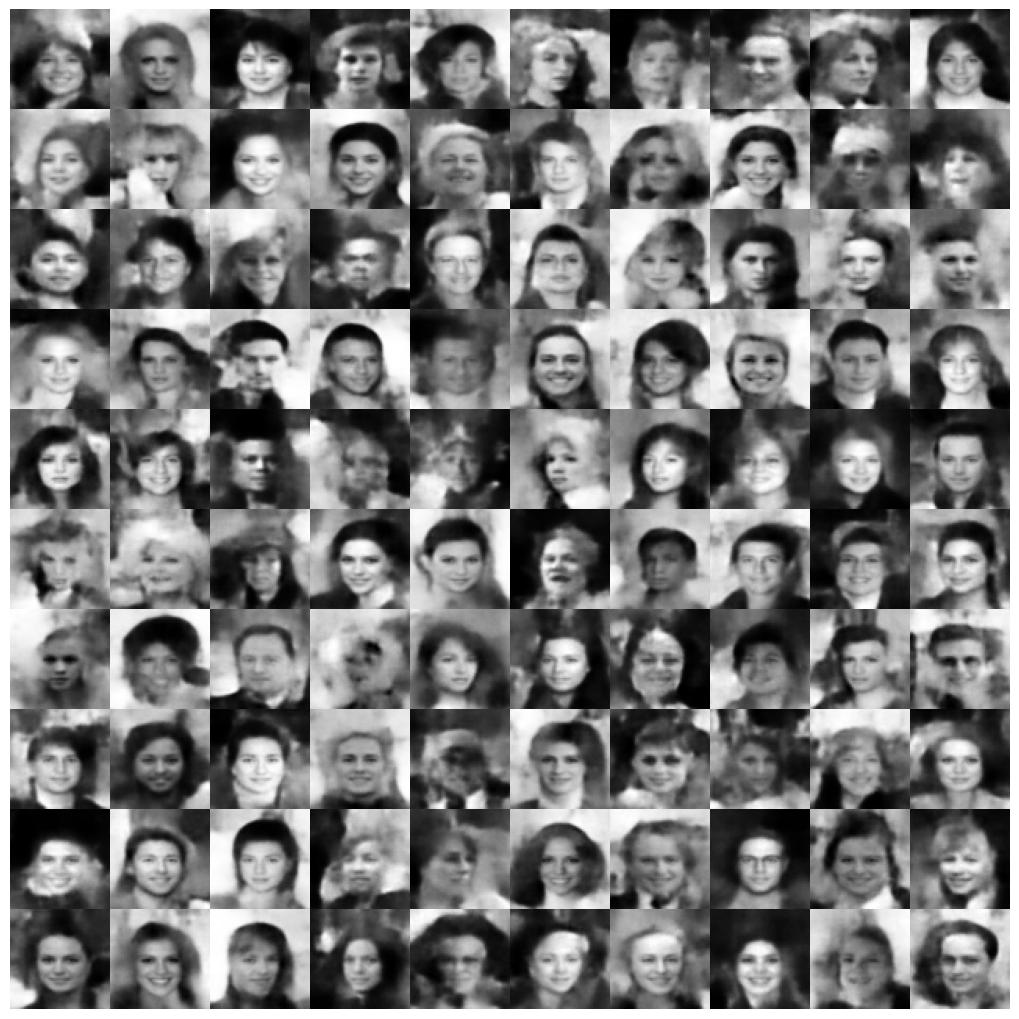

In [48]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def generate_new_images(model, n_images=16, image_size=64, device="cpu"):

    model.to(device)
    model.eval()

    latent_dim = 64

    cols = int(np.sqrt(n_images))
    rows = int(np.ceil(n_images / cols))

    fig, ax = plt.subplots(rows, cols, figsize=(10, 10))

    with torch.no_grad():

        for i in range(n_images):

            z = torch.randn(1, latent_dim, device=device)

            logits = model.decoder(z)

            img = logits[0,0].cpu()

            r = i // cols
            c = i % cols

            ax[r,c].imshow(img, cmap="gray")
            ax[r,c].axis("off")
            
    plt.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1,
        wspace=0,
        hspace=0
    )
    plt.show()
    
generate_new_images(loaded_model, n_images = 100, device="cpu")

## Single Sampling

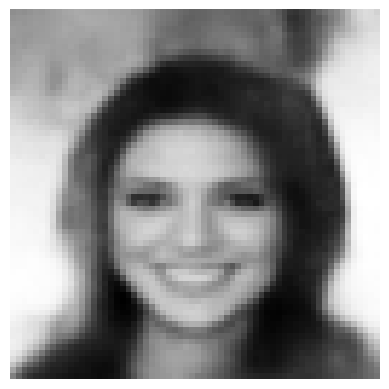

In [38]:
import matplotlib.pyplot as plt
z = torch.randn(1, latent_dim).to("cpu")
logits = loaded_model.decoder(z)
x_tilde = torch.sigmoid(logits)

img = x_tilde.cpu().view(64, 64)

plt.imshow(img.detach().numpy(), cmap="gray")
plt.axis("off")
plt.show()

In [32]:
images, labels = next(iter(loader))

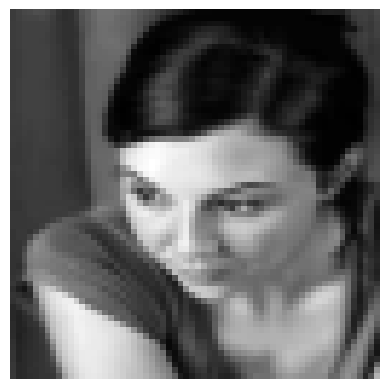

In [33]:
x = images[3].to(device)
plt.imshow(x.squeeze(0).cpu().detach().numpy(), cmap="gray")
plt.axis("off")
plt.show()


In [34]:
loaded_model = loaded_model.to(device)

In [35]:
_, reconstructed_img  = loaded_model(x.unsqueeze(0))

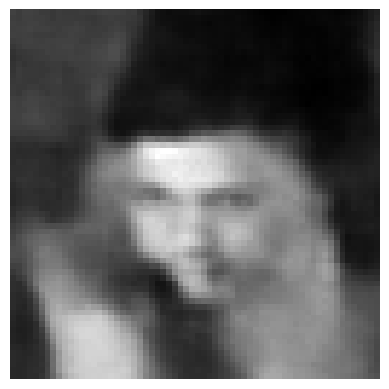

In [36]:
img = reconstructed_img.cpu().view(64, 64)

plt.imshow(img.detach().numpy(), cmap="gray")
plt.axis("off")
plt.show()

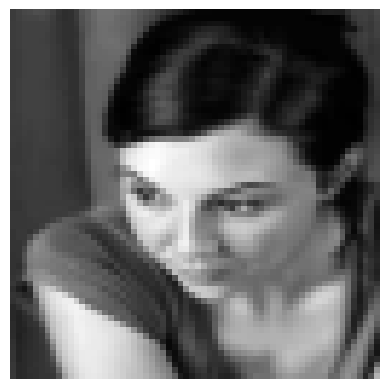

In [37]:
plt.imshow(x.squeeze(0).cpu().detach().numpy(), cmap="gray")
plt.axis("off")
plt.show()

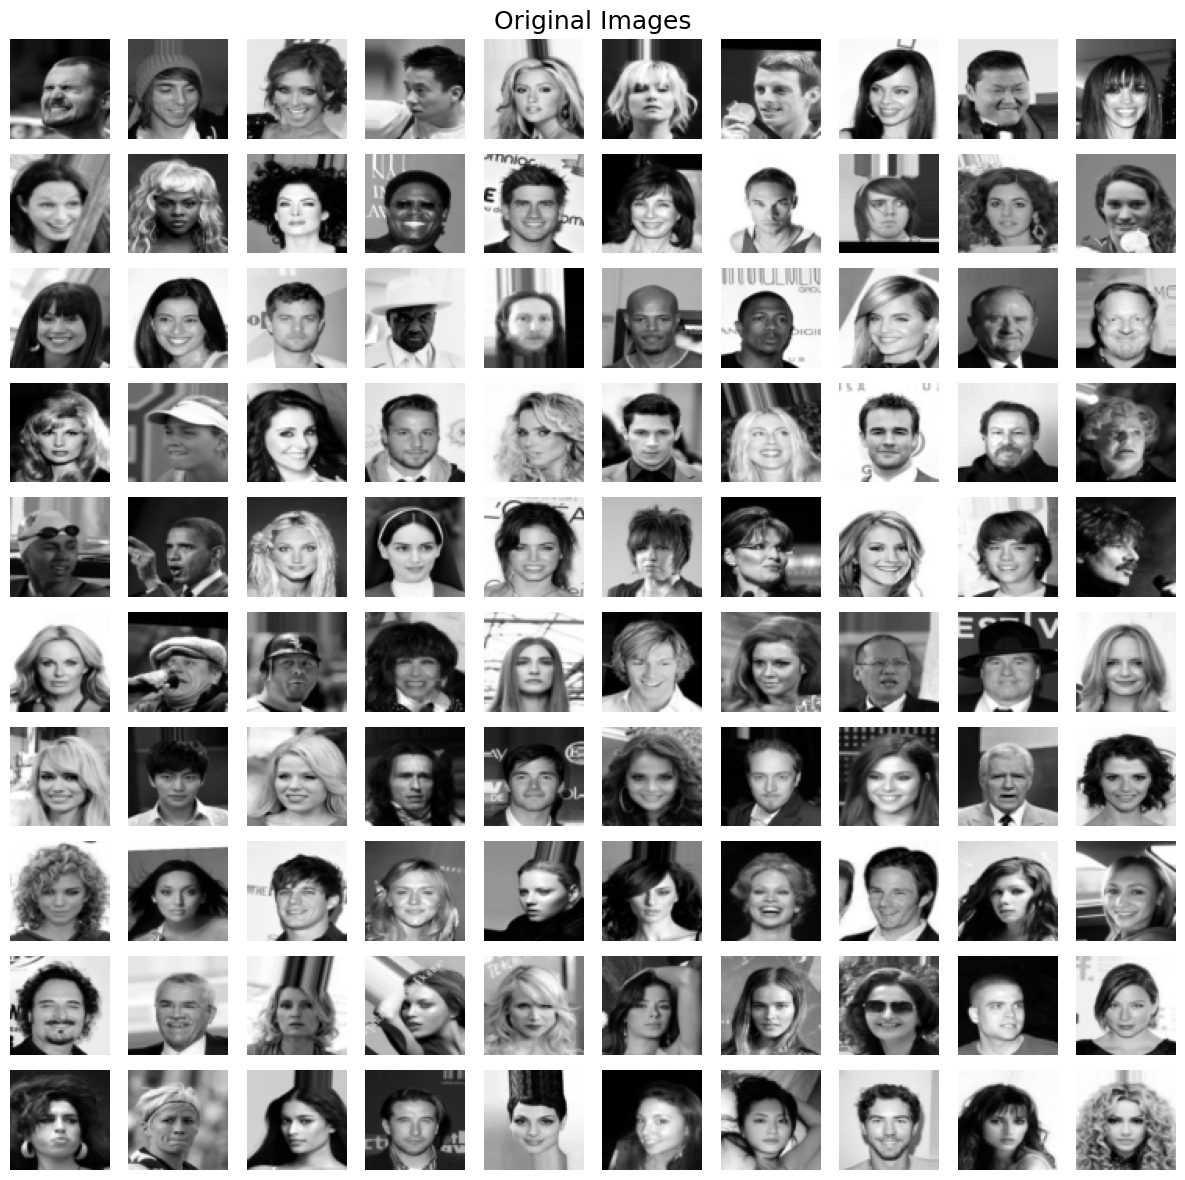

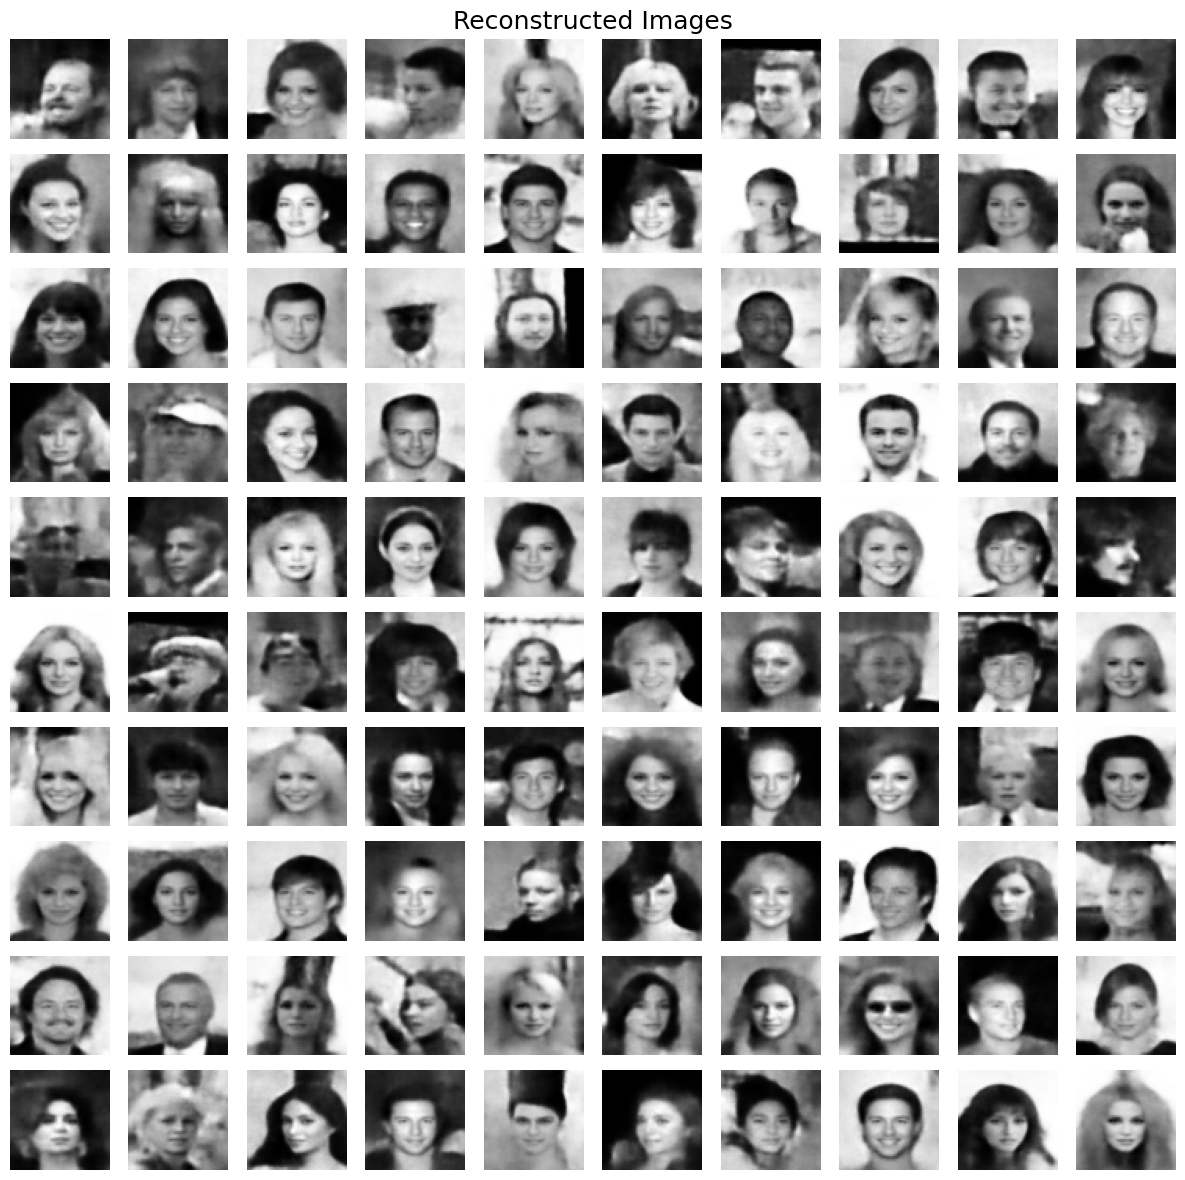

In [38]:
import random
import matplotlib.pyplot as plt

loaded_model = loaded_model.to(device)
loaded_model.eval()

# Pick 100 random indices
random_indices = random.sample(range(len(dataset)), 100)

# ---------------------------
# Plot Original Images
# ---------------------------
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for ax, idx in zip(axes.flatten(), random_indices):
    image, _ = dataset[idx]

    ax.imshow(
        image.squeeze(0).cpu().numpy(),
        cmap="gray"
    )
    ax.axis("off")

plt.suptitle("Original Images", fontsize=18)
plt.tight_layout()
plt.show()


# ---------------------------
# Plot Reconstructed Images
# ---------------------------
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

with torch.no_grad():
    for ax, idx in zip(axes.flatten(), random_indices):

        image, _ = dataset[idx]

        x = image.to(device)

        _, reconstructed_img = loaded_model(
            x.unsqueeze(0)
        )

        reconstructed_img = (
            reconstructed_img
            .cpu()
            .view(64, 64)
            .detach()
            .numpy()
        )

        ax.imshow(
            reconstructed_img,
            cmap="gray"
        )
        ax.axis("off")

plt.suptitle("Reconstructed Images", fontsize=18)
plt.tight_layout()
plt.show()